# 451 Financial Engineering: Programming Assignment 1
## AAPL Return Prediction — v3 (Expanded Exogenous Features + 1-Day & 5-Day Targets)

Michael Dawson


## Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pyarrow
import polars as pl

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay,
                             ConfusionMatrixDisplay, confusion_matrix,
                             precision_score, recall_score, f1_score)

import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

from scipy.stats import randint, uniform

## Retrieve Data — AAPL + Expanded Exogenous Set

| Ticker | What it is | Why it might help AAPL |
|---|---|---|
| `SPY` | S&P 500 ETF | Broad equity risk factor |
| `QQQ` | Nasdaq 100 ETF | Large-cap growth factor |
| `^VIX` | CBOE volatility index | Risk regime indicator |
| `^TNX` | 10-year Treasury yield | Rate sensitivity for growth stocks |
| `SOXX` | Semiconductor ETF | AAPL supply chain |
| `TSM`  | Taiwan Semiconductor | AAPL's chip manufacturer |
| `XLK`  | Tech sector ETF | Sector co-movement |
| `^N225` | Nikkei 225 | Overnight Asian sentiment |

Run this cell once; comment out afterward.

In [2]:
# Run once; comment out after CSVs exist.

import yfinance as yf

start_date = '2010-01-01'
end_date   = '2026-04-16'

tickers = [
    ('AAPL',  'aapl_historical_data.csv'),
    ('SPY',   'spy_historical_data.csv'),
    ('QQQ',   'qqq_historical_data.csv'),
    ('^VIX',  'vix_historical_data.csv'),
    ('^TNX',  'tnx_historical_data.csv'),
    ('SOXX',  'soxx_historical_data.csv'),
    ('TSM',   'tsm_historical_data.csv'),
    ('XLK',   'xlk_historical_data.csv'),
    ('^N225', 'n225_historical_data.csv'),
]

for sym, fname in tickers:
    print(f'pulling {sym}...')
    t = yf.Ticker(sym)
    h = t.history(start=start_date, end=end_date, auto_adjust=True)
    print(f'  rows: {len(h)}')
    h.to_csv(fname)

print('done')

pulling AAPL...
  rows: 4095
pulling SPY...
  rows: 4095
pulling QQQ...
  rows: 4095
pulling ^VIX...
  rows: 4095
pulling ^TNX...
  rows: 4093
pulling SOXX...
  rows: 4095
pulling TSM...
  rows: 4095
pulling XLK...
  rows: 4095
pulling ^N225...
  rows: 3982
done


## Feature Engineering — AAPL Stationary Features

Same as v2. Returns, percentage ratios, rolling-normalized quantities only.

In [3]:
aapl = pl.read_csv('aapl_historical_data.csv', try_parse_dates=True)
aapl = aapl.with_columns(pl.col('Date').cast(pl.Date))

drop_cols = [c for c in ['Dividends','Stock Splits','StockSplits','Capital Gains']
             if c in aapl.columns]
aapl = aapl.drop(drop_cols)

# core return
aapl = aapl.with_columns(
    np.log(pl.col('Close') / pl.col('Close').shift()).alias('LogReturn')
)

# return lags
aapl = aapl.with_columns(pl.col('LogReturn').shift(1).alias('RetLag1'))
aapl = aapl.with_columns(pl.col('LogReturn').shift(2).alias('RetLag2'))
aapl = aapl.with_columns(pl.col('LogReturn').shift(3).alias('RetLag3'))

# HML% and OMC% lags
aapl = aapl.with_columns(((pl.col('High') - pl.col('Low')) / pl.col('Close')).alias('HMLpct'))
aapl = aapl.with_columns(((pl.col('Open') - pl.col('Close')) / pl.col('Close')).alias('OMCpct'))
aapl = aapl.with_columns(pl.col('HMLpct').shift(1).alias('HMLpctLag1'))
aapl = aapl.with_columns(pl.col('HMLpct').shift(2).alias('HMLpctLag2'))
aapl = aapl.with_columns(pl.col('HMLpct').shift(3).alias('HMLpctLag3'))
aapl = aapl.with_columns(pl.col('OMCpct').shift(1).alias('OMCpctLag1'))
aapl = aapl.with_columns(pl.col('OMCpct').shift(2).alias('OMCpctLag2'))
aapl = aapl.with_columns(pl.col('OMCpct').shift(3).alias('OMCpctLag3'))

# volume ratio
aapl = aapl.with_columns(pl.col('Volume').shift(1).alias('Vol_t1'))
aapl = aapl.with_columns(pl.col('Vol_t1').rolling_mean(window_size=20).alias('Vol20'))
aapl = aapl.with_columns((pl.col('Vol_t1') / pl.col('Vol20')).alias('VolRatioLag1'))
aapl = aapl.with_columns(pl.col('VolRatioLag1').shift(1).alias('VolRatioLag2'))
aapl = aapl.with_columns(pl.col('VolRatioLag1').shift(2).alias('VolRatioLag3'))

# return EMAs
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=1, ignore_nulls=True).alias('RetEMA2'))
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=2, ignore_nulls=True).alias('RetEMA4'))
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=4, ignore_nulls=True).alias('RetEMA8'))

# realized vol
aapl = aapl.with_columns(pl.col('RetLag1').rolling_std(window_size=20).alias('RetVol20'))

print('aapl rows after AAPL feature engineering:', aapl.height)

aapl rows after AAPL feature engineering: 4095


## Define Both Targets

- `Target_1d` — 1 if next-day log return is positive, else 0. Same as v1/v2.
- `Target_5d` — 1 if sum of next 5 daily log returns is positive, else 0.

Both targets are computed *before* splitting into train/holdout. No features here, just labels.

In [4]:
# 1-day target (same as before): today's LogReturn sign
aapl = aapl.with_columns(
    pl.when(pl.col('LogReturn') > 0.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('Target_1d')
)

# 5-day target: sign of sum of today + next 4 days' log returns
# sum(LogReturn over t..t+4) is the forward 5-day return as seen from today
# We use rolling_sum on LogReturn then shift to look forward, OR equivalently
# compute sum of future returns. Polars doesn't have a clean "lead" for rolling,
# so we shift the LogReturn backward by -4 before summing... simpler: compute
# the 5-day forward return as log(Close_{t+5} / Close_t).
aapl = aapl.with_columns(
    np.log(pl.col('Close').shift(-4) / pl.col('Close').shift(1)).alias('Ret_5d_fwd')
)
aapl = aapl.with_columns(
    pl.when(pl.col('Ret_5d_fwd') > 0.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('Target_5d')
)

print('Target distribution (1-day):', dict(zip(*np.unique(aapl['Target_1d'].to_numpy(), return_counts=True))))
# 5-day target will have some nulls at the end where we can't look 5 days ahead
mask = aapl['Target_5d'].is_not_null().to_numpy()
print('Target distribution (5-day):', dict(zip(*np.unique(aapl['Target_5d'].to_numpy()[mask], return_counts=True))))

Target distribution (1-day): {np.int32(0): np.int64(1925), np.int32(1): np.int64(2170)}
Target distribution (5-day): {np.int32(0): np.int64(1754), np.int32(1): np.int64(2341)}


## Exogenous Features — Expanded Set

Eight exogenous series. For each, compute a 1-day-lagged log return signal. For VIX we additionally keep the level and change because it operates more like a regime indicator than a return series.

On the **Nikkei (^N225)**: the Nikkei closes at roughly 2 AM ET, before US markets open. Its latest close is technically available information before today's AAPL open. For methodological cleanliness and consistency with other series, we still lag it by 1 day — we're giving up some potential signal to keep the feature treatment uniform.

In [5]:
def load_return_series(path, prefix):
    """Load an exogenous series and compute a lagged log return."""
    df = pl.read_csv(path, try_parse_dates=True)
    df = df.with_columns(pl.col('Date').cast(pl.Date))
    df = df.select(['Date', 'Close']).rename({'Close': f'{prefix}_Close'})
    df = df.with_columns(
        np.log(pl.col(f'{prefix}_Close') / pl.col(f'{prefix}_Close').shift()).alias(f'{prefix}_Ret')
    )
    df = df.with_columns(pl.col(f'{prefix}_Ret').shift(1).alias(f'{prefix}_RetLag1'))
    return df.select(['Date', f'{prefix}_RetLag1'])

def load_vix(path):
    """Load VIX with both level and change lags (it's not a return series)."""
    df = pl.read_csv(path, try_parse_dates=True)
    df = df.with_columns(pl.col('Date').cast(pl.Date))
    df = df.select(['Date', 'Close']).rename({'Close': 'VIX_Close'})
    df = df.with_columns((pl.col('VIX_Close') - pl.col('VIX_Close').shift()).alias('VIX_Chg'))
    df = df.with_columns(pl.col('VIX_Close').shift(1).alias('VIX_LvlLag1'))
    df = df.with_columns(pl.col('VIX_Chg').shift(1).alias('VIX_ChgLag1'))
    return df.select(['Date', 'VIX_LvlLag1', 'VIX_ChgLag1'])

def load_tnx(path):
    """Load TNX (10Y yield) as a level-change series, not a return."""
    df = pl.read_csv(path, try_parse_dates=True)
    df = df.with_columns(pl.col('Date').cast(pl.Date))
    df = df.select(['Date', 'Close']).rename({'Close': 'TNX_Close'})
    df = df.with_columns((pl.col('TNX_Close') - pl.col('TNX_Close').shift()).alias('TNX_Chg'))
    df = df.with_columns(pl.col('TNX_Chg').shift(1).alias('TNX_ChgLag1'))
    return df.select(['Date', 'TNX_ChgLag1'])

spy   = load_return_series('spy_historical_data.csv',   'SPY')
qqq   = load_return_series('qqq_historical_data.csv',   'QQQ')
soxx  = load_return_series('soxx_historical_data.csv',  'SOXX')
tsm   = load_return_series('tsm_historical_data.csv',   'TSM')
xlk   = load_return_series('xlk_historical_data.csv',   'XLK')
n225  = load_return_series('n225_historical_data.csv',  'N225')
vix   = load_vix('vix_historical_data.csv')
tnx   = load_tnx('tnx_historical_data.csv')

for name, df in [('SPY',spy),('QQQ',qqq),('SOXX',soxx),('TSM',tsm),
                 ('XLK',xlk),('N225',n225),('VIX',vix),('TNX',tnx)]:
    print(f'{name:5s}  rows: {df.height}')

# join all on Date
aapl = aapl.join(spy,   on='Date', how='left')
aapl = aapl.join(qqq,   on='Date', how='left')
aapl = aapl.join(soxx,  on='Date', how='left')
aapl = aapl.join(tsm,   on='Date', how='left')
aapl = aapl.join(xlk,   on='Date', how='left')
aapl = aapl.join(n225,  on='Date', how='left')
aapl = aapl.join(vix,   on='Date', how='left')
aapl = aapl.join(tnx,   on='Date', how='left')

# report null counts
print()
print('null counts (features only, before drop_nulls):')
for col in aapl.columns:
    n = aapl[col].null_count()
    if n > 0 and col not in ['Target_5d', 'Ret_5d_fwd']:  # those nulls are expected at the tail
        print(f'  {col:20s} {n}')
print(f'\nrows before drop_nulls: {aapl.height}')

SPY    rows: 4095
QQQ    rows: 4095
SOXX   rows: 4095
TSM    rows: 4095
XLK    rows: 4095
N225   rows: 3982
VIX    rows: 4095
TNX    rows: 4093

null counts (features only, before drop_nulls):
  LogReturn            1
  RetLag1              2
  RetLag2              3
  RetLag3              4
  HMLpctLag1           1
  HMLpctLag2           2
  HMLpctLag3           3
  OMCpctLag1           1
  OMCpctLag2           2
  OMCpctLag3           3
  Vol_t1               1
  Vol20                20
  VolRatioLag1         20
  VolRatioLag2         21
  VolRatioLag3         22
  RetEMA2              2
  RetEMA4              2
  RetEMA8              2
  RetVol20             21
  SPY_RetLag1          2
  QQQ_RetLag1          2
  SOXX_RetLag1         2
  TSM_RetLag1          2
  XLK_RetLag1          2
  N225_RetLag1         960
  VIX_LvlLag1          1
  VIX_ChgLag1          2
  TNX_ChgLag1          4

rows before drop_nulls: 4095


In [6]:
# drop rows where ANY column is null (simpler, and we lose at most 4 trailing rows for Target_5d)
# this is cleaner than maintaining separate dataframes per target
aapl = aapl.drop_nulls()

print(f'final rows: {aapl.height}')
print(f'date range: {aapl["Date"].min()} to {aapl["Date"].max()}')

final rows: 3115
date range: 2010-02-04 to 2026-04-09


## Train / Hold-Out Split

In [7]:
HOLDOUT_FRAC = 0.15
GAP = 10

n_total   = int(aapl.height)
n_holdout = int(HOLDOUT_FRAC * n_total)
n_train   = n_total - n_holdout - GAP

print(f'n_total:   {n_total}')
print(f'n_holdout: {n_holdout}')
print(f'n_train:   {n_train}')

if n_train <= 0:
    raise ValueError('Not enough rows to split.')

train   = aapl.slice(0, n_train)
holdout = aapl.slice(n_train + GAP, n_holdout)

print(f'train:   {train.height} rows   ({train["Date"].min()} to {train["Date"].max()})')
print(f'holdout: {holdout.height} rows   ({holdout["Date"].min()} to {holdout["Date"].max()})')

n_total:   3115
n_holdout: 467
n_train:   2638
train:   2638 rows   (2010-02-04 to 2023-10-17)
holdout: 467 rows   (2023-11-07 to 2026-04-09)


## Build Feature Matrix

In [8]:
# drop raw OHLCV, same-day derived quantities, and targets
feature_drop = ['Date','Open','High','Low','Close','Volume',
                'LogReturn','Target_1d','Target_5d','Ret_5d_fwd',
                'HMLpct','OMCpct','Vol_t1','Vol20']

X_train_df   = train.drop(feature_drop)
X_holdout_df = holdout.drop(feature_drop)

featureNames = X_train_df.columns
print(f'number of features: {len(featureNames)}')
print('features:')
for f in featureNames:
    print(f'  {f}')

# both targets
y1_train = np.array(train['Target_1d'])
y1_holdout = np.array(holdout['Target_1d'])
y5_train = np.array(train['Target_5d'])
y5_holdout = np.array(holdout['Target_5d'])

print()
print('class balance — 1-day (train):  ', dict(zip(*np.unique(y1_train, return_counts=True))))
print('class balance — 1-day (holdout):', dict(zip(*np.unique(y1_holdout, return_counts=True))))
print('class balance — 5-day (train):  ', dict(zip(*np.unique(y5_train, return_counts=True))))
print('class balance — 5-day (holdout):', dict(zip(*np.unique(y5_holdout, return_counts=True))))

number of features: 25
features:
  RetLag1
  RetLag2
  RetLag3
  HMLpctLag1
  HMLpctLag2
  HMLpctLag3
  OMCpctLag1
  OMCpctLag2
  OMCpctLag3
  VolRatioLag1
  VolRatioLag2
  VolRatioLag3
  RetEMA2
  RetEMA4
  RetEMA8
  RetVol20
  SPY_RetLag1
  QQQ_RetLag1
  SOXX_RetLag1
  TSM_RetLag1
  XLK_RetLag1
  N225_RetLag1
  VIX_LvlLag1
  VIX_ChgLag1
  TNX_ChgLag1

class balance — 1-day (train):   {np.int32(0): np.int64(1216), np.int32(1): np.int64(1422)}
class balance — 1-day (holdout): {np.int32(0): np.int64(209), np.int32(1): np.int64(258)}
class balance — 5-day (train):   {np.int32(0): np.int64(1104), np.int32(1): np.int64(1534)}
class balance — 5-day (holdout): {np.int32(0): np.int64(212), np.int32(1): np.int64(255)}


## Scale Features

In [9]:
scaler = StandardScaler()
X_train   = scaler.fit_transform(np.array(X_train_df))
X_holdout = scaler.transform(np.array(X_holdout_df))

print('X_train shape:  ', X_train.shape)
print('X_holdout shape:', X_holdout.shape)

X_train shape:   (2638, 25)
X_holdout shape: (467, 25)


## Model Training Function

Wrap the three-model comparison so we can run it twice: once for the 1-day target, once for the 5-day target.

In [10]:
tscv = TimeSeriesSplit(n_splits=5, gap=10)

logit_dist = {'C': uniform(0.001, 10.0)}
rf_dist = {
    'n_estimators':     randint(200, 800),
    'max_depth':        randint(3, 15),
    'min_samples_leaf': randint(1, 20),
    'max_features':     ['sqrt', 'log2', 0.5],
}
xgb_dist = {
    'n_estimators':     randint(100, 600),
    'max_depth':        randint(2, 8),
    'learning_rate':    uniform(0.01, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'reg_alpha':        uniform(0.0, 1.0),
    'reg_lambda':       uniform(0.0, 1.0),
}

def run_three_model_comparison(X_tr, y_tr, X_ho, y_ho, target_label):
    """Train logit/RF/XGB on (X_tr, y_tr), evaluate on (X_ho, y_ho). Return results dict."""
    print(f'--- training for target: {target_label} ---')
    
    logit_search = RandomizedSearchCV(
        LogisticRegression(max_iter=2000, solver='lbfgs'),
        logit_dist, n_iter=20, scoring='roc_auc', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
    )
    logit_search.fit(X_tr, y_tr)
    print(f'Logistic  — CV AUC: {logit_search.best_score_:.4f}')
    
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        rf_dist, n_iter=40, scoring='roc_auc', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
    )
    rf_search.fit(X_tr, y_tr)
    print(f'RF        — CV AUC: {rf_search.best_score_:.4f}')
    
    xgb_search = RandomizedSearchCV(
        XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                      tree_method='hist', random_state=42),
        xgb_dist, n_iter=50, scoring='roc_auc', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
    )
    xgb_search.fit(X_tr, y_tr)
    print(f'XGBoost   — CV AUC: {xgb_search.best_score_:.4f}')
    
    def eval_on_holdout(model, name):
        pred = model.predict(X_ho)
        prob = model.predict_proba(X_ho)[:, 1]
        return {
            'model':     name,
            'cv_auc':    None,
            'accuracy':  accuracy_score(y_ho, pred),
            'AUC':       roc_auc_score(y_ho, prob),
            'precision': precision_score(y_ho, pred),
            'recall':    recall_score(y_ho, pred),
            'f1':        f1_score(y_ho, pred),
        }
    
    maj = int(np.bincount(y_tr).argmax())
    y_maj = np.full_like(y_ho, maj)
    
    rows = [
        {'model': 'Majority class', 'cv_auc': None, 'accuracy': accuracy_score(y_ho, y_maj),
         'AUC': 0.5, 'precision': np.nan, 'recall': np.nan, 'f1': np.nan},
        {**eval_on_holdout(logit_search.best_estimator_, 'Logistic Regression'), 'cv_auc': logit_search.best_score_},
        {**eval_on_holdout(rf_search.best_estimator_,    'Random Forest'),       'cv_auc': rf_search.best_score_},
        {**eval_on_holdout(xgb_search.best_estimator_,   'XGBoost'),             'cv_auc': xgb_search.best_score_},
    ]
    
    return rows, {
        'Logistic Regression': logit_search.best_estimator_,
        'Random Forest':       rf_search.best_estimator_,
        'XGBoost':             xgb_search.best_estimator_,
    }

## Run Both Targets

This cell takes a while — it trains six models total (three for each target).

In [11]:
results_1d, models_1d = run_three_model_comparison(X_train, y1_train, X_holdout, y1_holdout, '1-day direction')
print()
results_5d, models_5d = run_three_model_comparison(X_train, y5_train, X_holdout, y5_holdout, '5-day direction')

--- training for target: 1-day direction ---
Logistic  — CV AUC: 0.5319
RF        — CV AUC: 0.5392
XGBoost   — CV AUC: 0.5490

--- training for target: 5-day direction ---
Logistic  — CV AUC: 0.5268
RF        — CV AUC: 0.5184
XGBoost   — CV AUC: 0.5218


## Results Table — 1-Day Target

In [12]:
def print_results(rows, label, y_ho):
    print('=' * 80)
    print(f'HOLD-OUT RESULTS — {label}  ({len(y_ho)} rows)')
    print('=' * 80)
    print(f'{"model":22s}  {"CV AUC":>7s}  {"acc":>7s}  {"AUC":>7s}  {"prec":>7s}  {"rec":>7s}  {"f1":>7s}')
    print('-' * 80)
    def fmt(x):
        if x is None:
            return '   n/a '
        if isinstance(x, float) and np.isnan(x):
            return '   n/a '
        return f'{x:7.4f}'
    for r in rows:
        print(f'{r["model"]:22s}  {fmt(r["cv_auc"])}  {fmt(r["accuracy"])}  {fmt(r["AUC"])}  '
              f'{fmt(r["precision"])}  {fmt(r["recall"])}  {fmt(r["f1"])}')

print_results(results_1d, '1-DAY DIRECTION', y1_holdout)

HOLD-OUT RESULTS — 1-DAY DIRECTION  (467 rows)
model                    CV AUC      acc      AUC     prec      rec       f1
--------------------------------------------------------------------------------
Majority class             n/a    0.5525   0.5000     n/a      n/a      n/a 
Logistic Regression      0.5319   0.5246   0.5237   0.5523   0.7364   0.6312
Random Forest            0.5392   0.5139   0.4801   0.5480   0.6860   0.6093
XGBoost                  0.5490   0.5289   0.5228   0.5699   0.6008   0.5849


## Results Table — 5-Day Target

In [13]:
print_results(results_5d, '5-DAY DIRECTION', y5_holdout)

HOLD-OUT RESULTS — 5-DAY DIRECTION  (467 rows)
model                    CV AUC      acc      AUC     prec      rec       f1
--------------------------------------------------------------------------------
Majority class             n/a    0.5460   0.5000     n/a      n/a      n/a 
Logistic Regression      0.5268   0.5375   0.5108   0.5486   0.8627   0.6707
Random Forest            0.5184   0.5525   0.5450   0.5569   0.8824   0.6829
XGBoost                  0.5218   0.5589   0.5227   0.5579   0.9255   0.6962


## Diagnostics on the Best 5-Day Model

If the 5-day target delivers the expected lift, we care most about diagnosing that model.

best 5-day model: Random Forest

              precision    recall  f1-score   support

           0       0.52      0.16      0.24       212
           1       0.56      0.88      0.68       255

    accuracy                           0.55       467
   macro avg       0.54      0.52      0.46       467
weighted avg       0.54      0.55      0.48       467



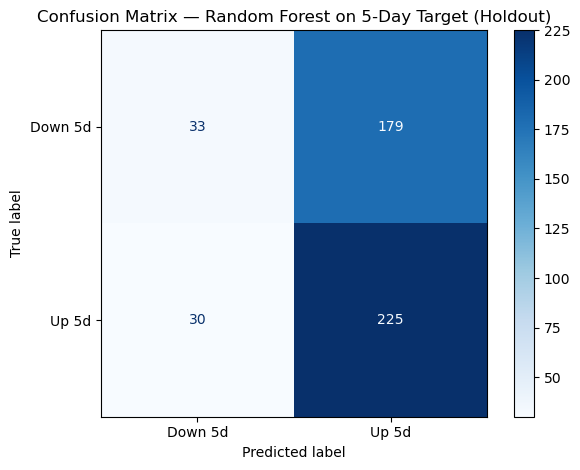

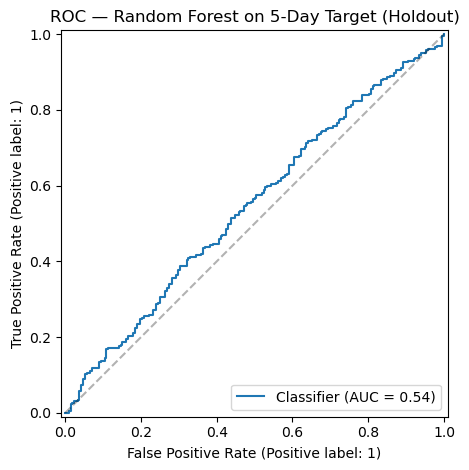

In [14]:
# pick best 5-day model by holdout AUC
model_results = [r for r in results_5d if r['model'] != 'Majority class']
best_5d_name = max(model_results, key=lambda r: r['AUC'])['model']
best_5d_model = models_5d[best_5d_name]
print(f'best 5-day model: {best_5d_name}')

y5_pred = best_5d_model.predict(X_holdout)
y5_prob = best_5d_model.predict_proba(X_holdout)[:, 1]

print()
print(classification_report(y5_holdout, y5_pred))

ConfusionMatrixDisplay.from_predictions(
    y5_holdout, y5_pred,
    display_labels=['Down 5d','Up 5d'],
    cmap=plt.cm.Blues,
)
plt.title(f'Confusion Matrix — {best_5d_name} on 5-Day Target (Holdout)')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y5_holdout, y5_prob)
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.title(f'ROC — {best_5d_name} on 5-Day Target (Holdout)')
plt.tight_layout()
plt.show()

## Feature Importance — XGBoost on Both Targets

Does the feature-importance ranking differ between 1-day and 5-day targets? If the longer horizon surfaces fundamentally different features (e.g. VIX level or realized vol becoming dominant), that tells us which signals actually carry information at different horizons.

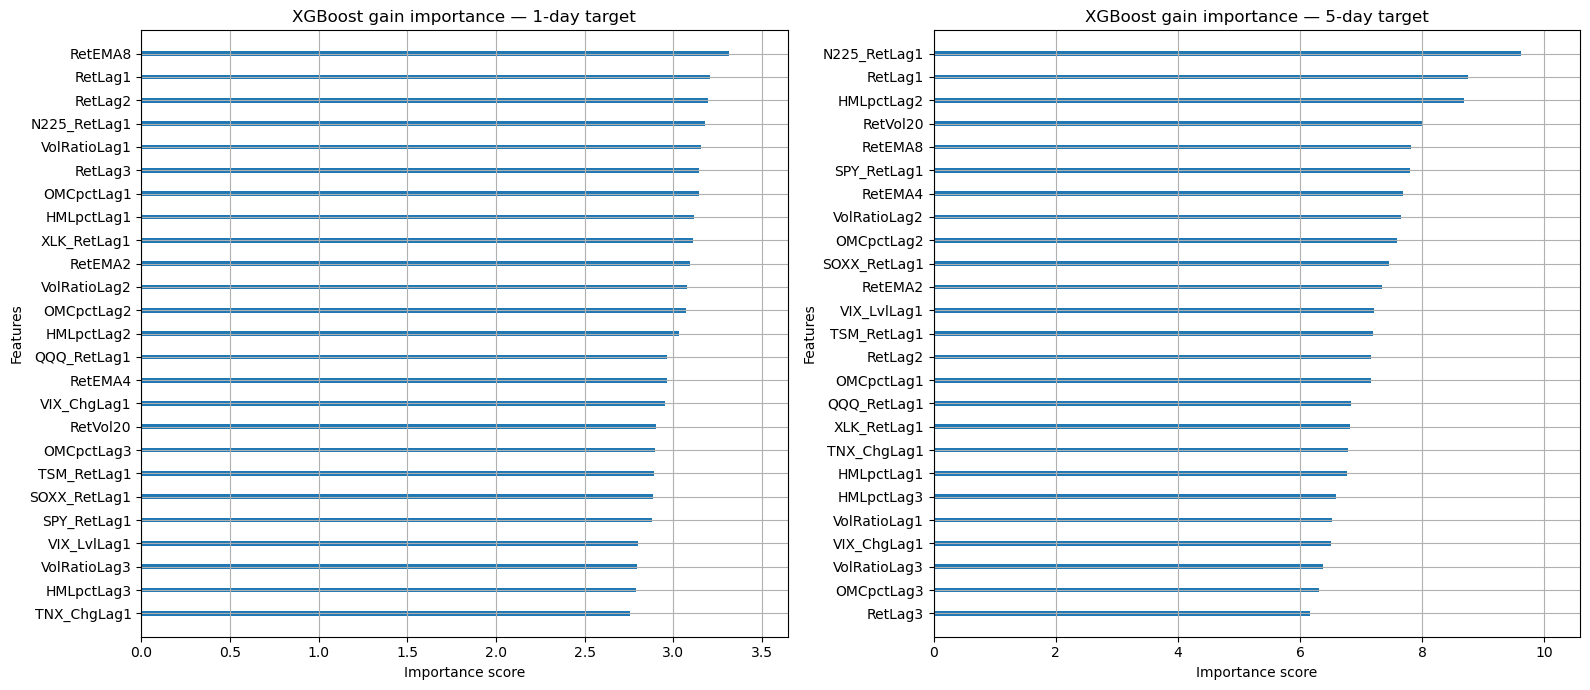

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

b1 = models_1d['XGBoost'].get_booster()
b1.feature_names = list(featureNames)
plot_importance(b1, ax=axes[0], importance_type='gain', show_values=False)
axes[0].set_title('XGBoost gain importance — 1-day target')

b5 = models_5d['XGBoost'].get_booster()
b5.feature_names = list(featureNames)
plot_importance(b5, ax=axes[1], importance_type='gain', show_values=False)
axes[1].set_title('XGBoost gain importance — 5-day target')

plt.tight_layout()
plt.show()

## Summary

v3 additions:

- **Expanded exogenous set:** SOXX (semiconductors), TSM (AAPL chip supplier), XLK (tech sector), N225 (Nikkei overnight)
- **Two horizons:** 1-day and 5-day directional targets, same feature set, same train/holdout split

Things to address in the write-up:

1. **Comparison across horizons.** How much better (if at all) is 5-day prediction vs 1-day? This speaks to a core ML-in-finance question: at what horizon does daily lagged price data actually carry signal?
2. **Feature importance across horizons.** Do the new supply-chain features (TSM, SOXX) show up prominently? If yes, that's a real finding about what drives AAPL.
3. **Nikkei's role.** Overnight sentiment is the kind of cross-geography effect that's harder to arbitrage away than pure US price history. Does it contribute?
4. **EMH framing, revisited.** Even at 5-day horizon on a liquid mega-cap, beating baseline by more than a couple percentage points is historically difficult. Whatever number you land on, frame it against that context.